In [ ]:
import _thread
import time

def input_thread(a_list):
    input()             # use input() in Python3
    a_list.append(True)
    
def do_stuff():
    a_list = []
    _thread.start_new_thread(input_thread, (a_list,))
    num = 1
    while not a_list:
        num += 1
        print(num)
        time.sleep(0.5)

In [ ]:
from queue import Queue
import threading
import time
import numpy as np

count_queue = Queue(maxsize=1)
counter = 0

def count_func():
    global counter
    while True: #need a loop in the multithreaded funtion for it to continuously run
        if count_queue.full():
            count_queue.get_nowait()
        count_queue.put(counter)
        counter += 1
        time.sleep(0.05)   # control update rate

threading.Thread(target=count_func, daemon=True).start()

counter2 = 0
while True:
    time.sleep(np.random.random())
    print(f'while loop runs {counter2}, function runs {count_queue.get()}')
    counter2 += 1

In [ ]:
from queue import Queue
import threading
import time
import Hand_tracking as ht

client = ht.create_client(port=8000)
frame_queue = Queue(maxsize=1)

def frame_producer(stop_event):
    try:
        for frame in client.iter_events():
            if stop_event.is_set():
                break

            try:
                frame_queue.put(frame, block=False)
            except:
                frame_queue.get_nowait()
                frame_queue.put(frame)

    finally:
        # VERY IMPORTANT: close socket
        try:
            client.close()
        except:
            pass

stop_event = threading.Event()
producer_thread = threading.Thread(
    target=frame_producer,
    args=(stop_event,),
    daemon=False
)
producer_thread.start()


while True:
    time.sleep(1)
    try:
        frame = frame_queue.get_nowait()
        print(f'\rGot frame', end='')
    except:
        print('\rNo frame yet', end='')

In [ ]:
# Source - https://stackoverflow.com/a/70558417
# Posted by RSale, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-05, License - CC BY-SA 4.0

import pandas as pd
def clearvars():    
    for el in sorted(globals()):
        if '__' not in el:
                print(f'deleted: {el}')
                del el
clearvars()



In [ ]:
# import Hand_tracking as ht
from hand_tracking_sdk import HTSClient, HTSClientConfig, JointName, StreamOutput
from queue import Queue
import threading
import time
import Hand_tracking as ht

client = ht.create_client(port=8000)

frame_queue = Queue(maxsize=1)

COUNTER = 0
def frame_producer():
    global client
    for frame in client.iter_events():
        # COUNTER += 1
        if frame_queue.full():
            frame_queue.get_nowait()
            frame_queue.put(frame)


threading.Thread(target=frame_producer, daemon=True).start()

while True:
    # time.sleep(1)
    try:
        frame = frame_queue.get_nowait()
        curls = ht.normalize_curl(ht.finger_curls(frame_queue.get()))
        print(f'\rGot curls: {curls}', end='')
    except:
        print('\rNo frame yet', end='')
    # curls = ht.normalize_curl(ht.finger_curls(frame_queue.get()))
    # print(end='\r')
    # for curl in curls:
    #     print('index', ht.draw_bar(curl),end='')

In [ ]:
import Multi_servo_control as msc
while True:
    x = int(input())
    msc.set_intensity(x+50,2)
    msc.set_intensity(x+40,4)
    msc.set_intensity(x+30,6)

In [8]:

import matplotlib.pyplot as plt
class linearized_mapper:
    def __init__(self, raw_data):
        raw_data = np.asarray(raw_data)

        # Ensure monotonically increasing data
        raw_data = np.sort(raw_data)

        self.input_scale = np.linspace(0, 100, len(raw_data))
        self.output_data = raw_data

    def __call__(self, x):
        x = np.clip(x, 0, 100)
        return np.interp(x, self.input_scale, self.output_data)
    
data = np.exp(np.linspace(0, 5, 1000))  # exponential curve

mapper = linearized_mapper(data)

mapper(0)     # smallest value
mapper(50)    # middle of stretche

12.182532107271957

In [15]:
entries = [[20, [1,2,3],[4,5,6]], [30, [2,4,6],[8,10,12]]]
sd= {}
for stim, (sd['IM'], sd['RP'], sd['T']), (sd['IMCURL'],sd['IMCURL'],sd['TCURL']) in entries:
    print(sd)

{'IM': 1, 'RP': 2, 'T': 3, 'IMCURL': 5, 'TCURL': 6}
{'IM': 2, 'RP': 4, 'T': 6, 'IMCURL': 10, 'TCURL': 12}


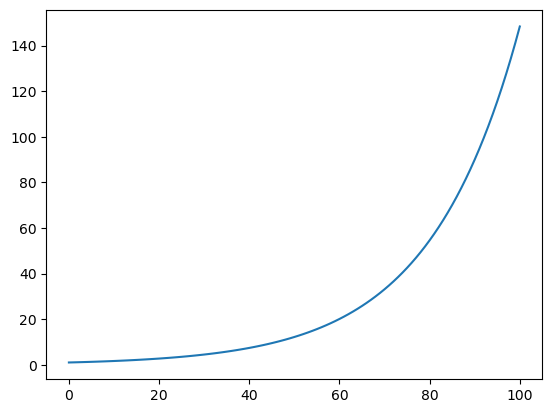

In [11]:
mapvals = [mapper(i) for i in range(0,101)]
plt.plot(range(0,101),mapvals)